# FIFA World Cup Performance Analysis (1930–2022)

## Research Question

Which countries have achieved the greatest FIFA World Cup success relative to their population?

## Project Goal

This project analyzes FIFA World Cup match data from 1930–2022 using SQL in Jupyter Notebook. The main goal is to identify countries that overperform relative to population and highlight the greatest World Cup underdogs.

## Tools Used

- Python
- DuckDB SQL
- Pandas
- Matplotlib
 

## Business Problem

Raw World Cup statistics such as total wins, championships, or goals scored often favor countries with larger populations and longer football traditions.

However, those measures do not account for the size of a country's available talent pool.

This project looks beyond total success and asks which countries have achieved the most World Cup success relative to their population.

## Objectives

- Load FIFA World Cup match data from 1930–2022.
- Explore tournament-level and country-level trends using SQL.
- Calculate wins, goals, appearances, and knockout-stage performance.
- Create a country-level performance score.
- Later join population data to calculate a World Cup Efficiency Index.
- Identify the strongest overperforming countries.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect(database=':memory:')

## Load Dataset

The dataset contains FIFA World Cup matches from 1930 through 2022.

In [2]:
conn.sql("""
CREATE TABLE matches AS
SELECT *
FROM read_csv_auto('/Users/ajnursivac/Desktop/Projects/matches_1930_2022.csv');
""")
         



In [3]:
conn.sql("""
SELECT *
FROM matches
LIMIT 5;
""").df()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4,3,2.2,2,Lionel Scaloni,Lionel Messi,...,None,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",None,None,None,None,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,<NA>,1,1.2,<NA>,Zlatko Dalić,Luka Modrić,...,None,None,None,None,None,None,None,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,<NA>,0,0.9,<NA>,Didier Deschamps,Hugo Lloris,...,None,None,None,None,None,None,None,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,<NA>,0,0.5,<NA>,Lionel Scaloni,Lionel Messi,...,None,None,None,None,None,None,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,<NA>,0,0.9,<NA>,Hoalid Regragui,Romain Saïss,...,None,None,None,None,Walid Cheddira · 90+3,None,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


## Dataset Structure

Before analyzing the data, I inspected the columns and data types to understand what information is available.

In [4]:
conn.sql("""
DESCRIBE matches;
""").df()

,column_name,column_type,null,key,default,extra
0,home_team,VARCHAR,YES,None,None,None
1,away_team,VARCHAR,YES,None,None,None
2,home_score,BIGINT,YES,None,None,None
3,home_xg,DOUBLE,YES,None,None,None
4,home_penalty,BIGINT,YES,None,None,None
5,away_score,BIGINT,YES,None,None,None
6,away_xg,DOUBLE,YES,None,None,None
7,away_penalty,BIGINT,YES,None,None,None
8,home_manager,VARCHAR,YES,None,None,None
9,home_captain,VARCHAR,YES,None,None,None


## Basic Dataset Overview

In [5]:
conn.sql("""
SELECT 
    COUNT(*) AS total_matches,
    COUNT(DISTINCT Year) AS total_world_cups,
    MIN(Year) AS first_year,
    MAX(Year) AS last_year
FROM matches;
""").df()

,total_matches,total_world_cups,first_year,last_year
0,964,22,1930,2022


In [6]:
conn.sql("""
SELECT 
    COUNT(DISTINCT team) AS total_countries
FROM (
    SELECT home_team AS team FROM matches
    UNION
    SELECT away_team AS team FROM matches
);
""").df()

,total_countries
0,86


## Matches by Tournament Year

In [7]:
matches_by_year = conn.sql("""
SELECT 
    Year,
    COUNT(*) AS total_matches
FROM matches
GROUP BY Year
ORDER BY Year;
""").df()

matches_by_year

,Year,total_matches
0,1930,18
1,1934,17
2,1938,18
3,1950,22
4,1954,26
5,1958,35
6,1962,32
7,1966,32
8,1970,32
9,1974,38


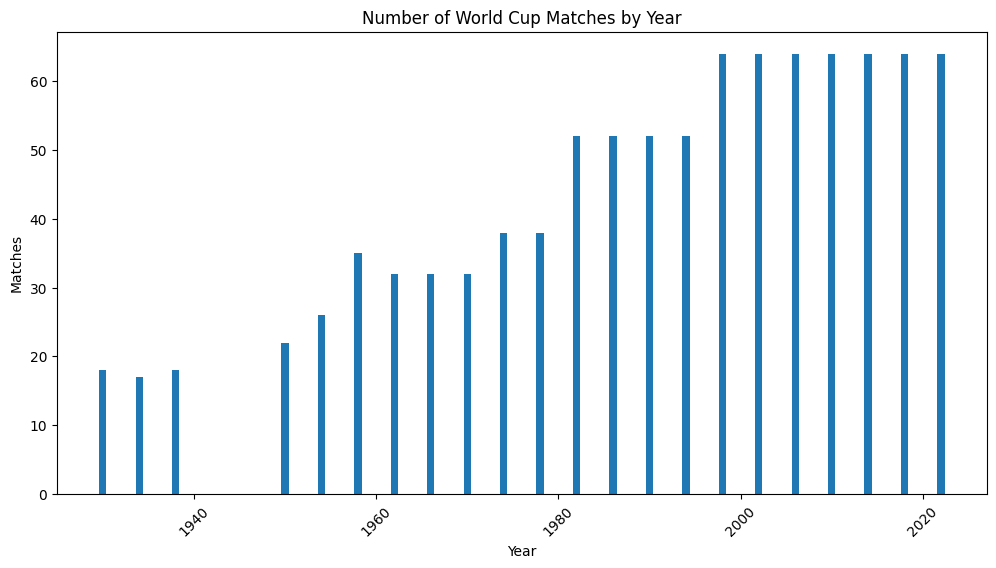

In [8]:
plt.figure(figsize=(12,6))
plt.bar(matches_by_year['Year'], matches_by_year['total_matches'])
plt.title('Number of World Cup Matches by Year')
plt.xlabel('Year')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.show()

## Create Team-Level Match Table

The original dataset stores each match with a home team and an away team. For country-level analysis, I transformed the data so each row represents one team's result in one match.

In [9]:
conn.sql("""
CREATE TABLE team_matches AS

SELECT
    Year,
    Round,
    Date,
    Host,
    home_team AS team,
    away_team AS opponent,
    home_score AS goals_for,
    away_score AS goals_against,
    home_penalty AS penalty_goals_for,
    away_penalty AS penalty_goals_against,
    CASE
        WHEN home_score > away_score THEN 'Win'
        WHEN home_score < away_score THEN 'Loss'
        WHEN home_score = away_score AND home_penalty > away_penalty THEN 'Win'
        WHEN home_score = away_score AND home_penalty < away_penalty THEN 'Loss'
        ELSE 'Draw'
    END AS result
FROM matches

UNION ALL

SELECT
    Year,
    Round,
    Date,
    Host,
    away_team AS team,
    home_team AS opponent,
    away_score AS goals_for,
    home_score AS goals_against,
    away_penalty AS penalty_goals_for,
    home_penalty AS penalty_goals_against,
    CASE
        WHEN away_score > home_score THEN 'Win'
        WHEN away_score < home_score THEN 'Loss'
        WHEN away_score = home_score AND away_penalty > home_penalty THEN 'Win'
        WHEN away_score = home_score AND away_penalty < home_penalty THEN 'Loss'
        ELSE 'Draw'
    END AS result
FROM matches;
""")

In [10]:
conn.sql("""
SELECT *
FROM team_matches
LIMIT 10;
""").df()

,Year,Round,Date,Host,team,opponent,goals_for,goals_against,penalty_goals_for,penalty_goals_against,result
0,2022,Final,2022-12-18,Qatar,Argentina,France,3,3,4,2,Win
1,2022,Third-place match,2022-12-17,Qatar,Croatia,Morocco,2,1,<NA>,<NA>,Win
2,2022,Semi-finals,2022-12-14,Qatar,France,Morocco,2,0,<NA>,<NA>,Win
3,2022,Semi-finals,2022-12-13,Qatar,Argentina,Croatia,3,0,<NA>,<NA>,Win
4,2022,Quarter-finals,2022-12-10,Qatar,Morocco,Portugal,1,0,<NA>,<NA>,Win
5,2022,Quarter-finals,2022-12-10,Qatar,England,France,1,2,<NA>,<NA>,Loss
6,2022,Quarter-finals,2022-12-09,Qatar,Croatia,Brazil,1,1,4,2,Win
7,2022,Quarter-finals,2022-12-09,Qatar,Netherlands,Argentina,2,2,3,4,Loss
8,2022,Round of 16,2022-12-06,Qatar,Morocco,Spain,0,0,3,0,Win
9,2022,Round of 16,2022-12-06,Qatar,Portugal,Switzerland,6,1,<NA>,<NA>,Win


## Country Match Performance

This section calculates each country's total matches, wins, draws, losses, goals scored, and goals allowed.

In [11]:
country_match_stats = conn.sql("""
SELECT
    team,
    COUNT(*) AS matches_played,
    SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) AS wins,
    SUM(CASE WHEN result = 'Draw' THEN 1 ELSE 0 END) AS draws,
    SUM(CASE WHEN result = 'Loss' THEN 1 ELSE 0 END) AS losses,
    SUM(goals_for) AS goals_for,
    SUM(goals_against) AS goals_against,
    SUM(goals_for) - SUM(goals_against) AS goal_difference,
    ROUND(100.0 * SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) / COUNT(*), 2) AS win_percentage
FROM team_matches
GROUP BY team
ORDER BY wins DESC;
""").df()

country_match_stats.head(15)

,team,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,win_percentage
0,Brazil,114,79.0,14.0,21.0,237.0,108.0,129.0,69.30
1,Argentina,88,53.0,10.0,25.0,152.0,101.0,51.0,60.23
2,Italy,83,46.0,17.0,20.0,128.0,77.0,51.0,55.42
3,France,73,41.0,9.0,23.0,136.0,85.0,51.0,56.16
4,Germany,56,38.0,6.0,12.0,126.0,67.0,59.0,67.86
5,West Germany,56,34.0,11.0,11.0,106.0,63.0,43.0,60.71
6,England,74,33.0,18.0,23.0,104.0,68.0,36.0,44.59
7,Spain,67,32.0,12.0,23.0,108.0,75.0,33.0,47.76
8,Netherlands,55,31.0,10.0,14.0,96.0,52.0,44.0,56.36
9,Uruguay,59,26.0,12.0,21.0,89.0,76.0,13.0,44.07


## Countries with the Most World Cup Matches

In [12]:
conn.sql("""
SELECT
    team,
    COUNT(*) AS matches_played
FROM team_matches
GROUP BY team
ORDER BY matches_played DESC
LIMIT 15;
""").df()

,team,matches_played
0,Brazil,114
1,Argentina,88
2,Italy,83
3,England,74
4,France,73
5,Spain,67
6,Mexico,60
7,Uruguay,59
8,West Germany,56
9,Germany,56


## Countries with the Most Wins

In [13]:
top_wins = conn.sql("""
SELECT
    team,
    SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) AS wins
FROM team_matches
GROUP BY team
ORDER BY wins DESC
LIMIT 15;
""").df()

top_wins

,team,wins
0,Brazil,79.0
1,Argentina,53.0
2,Italy,46.0
3,France,41.0
4,Germany,38.0
5,West Germany,34.0
6,England,33.0
7,Spain,32.0
8,Netherlands,31.0
9,Uruguay,26.0


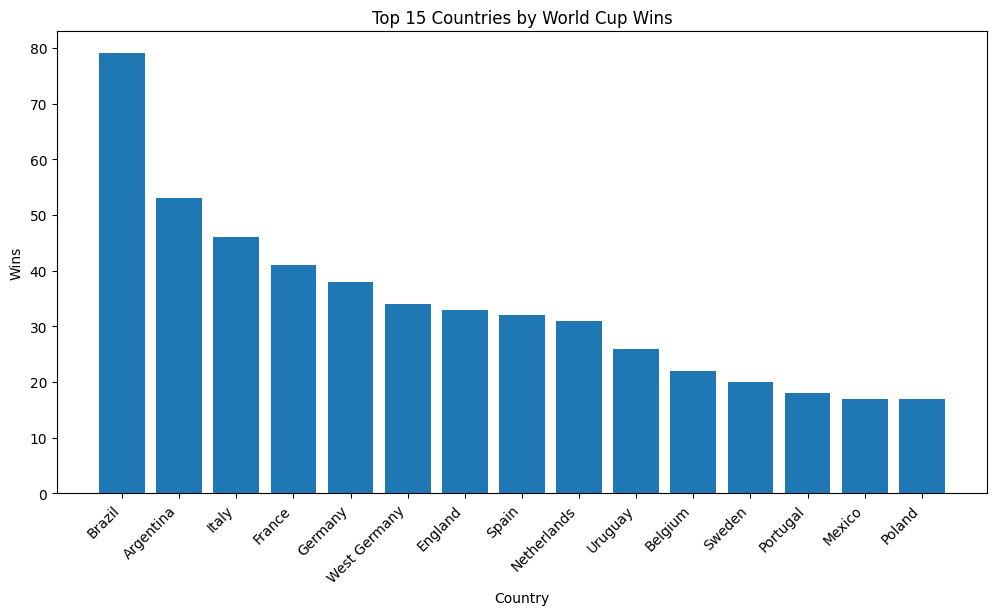

In [14]:
plt.figure(figsize=(12,6))
plt.bar(top_wins['team'], top_wins['wins'])
plt.title('Top 15 Countries by World Cup Wins')
plt.xlabel('Country')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.show()

## Countries with the Most Goals Scored

In [15]:
top_goals = conn.sql("""
SELECT
    team,
    SUM(goals_for) AS goals_scored
FROM team_matches
GROUP BY team
ORDER BY goals_scored DESC
LIMIT 15;
""").df()

top_goals

,team,goals_scored
0,Brazil,237.0
1,Argentina,152.0
2,France,136.0
3,Italy,128.0
4,Germany,126.0
5,Spain,108.0
6,West Germany,106.0
7,England,104.0
8,Netherlands,96.0
9,Uruguay,89.0


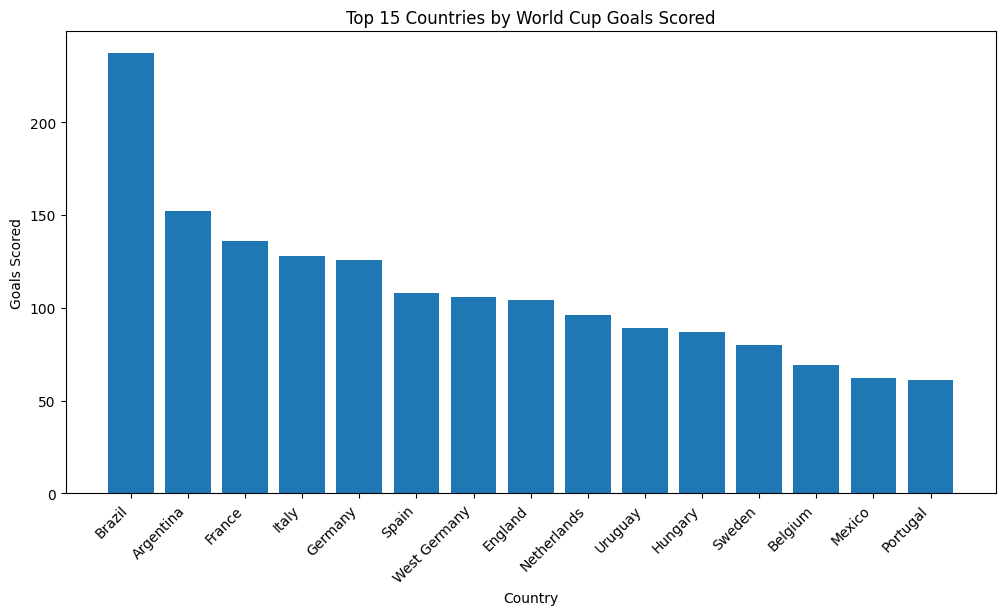

In [16]:
plt.figure(figsize=(12,6))
plt.bar(top_goals['team'], top_goals['goals_scored'])
plt.title('Top 15 Countries by World Cup Goals Scored')
plt.xlabel('Country')
plt.ylabel('Goals Scored')
plt.xticks(rotation=45, ha='right')
plt.show()


## Knockout Stage Performance

To measure deeper tournament success, I created indicators for appearances in later rounds such as quarterfinals, semifinals, third-place matches, and finals.

In [17]:
conn.sql("""
SELECT DISTINCT Round
FROM matches
ORDER BY Round;
""").df()

,Round
0,Final
1,Final stage
2,First group stage
3,First round
4,Group stage
5,Group stage play-off
6,Quarter-finals
7,Round of 16
8,Second group stage
9,Second round


In [18]:
knockout_stats = conn.sql("""
SELECT
    team,
    SUM(CASE WHEN Round ILIKE '%Final%' THEN 1 ELSE 0 END) AS final_related_matches,
    SUM(CASE WHEN Round ILIKE '%Semi%' THEN 1 ELSE 0 END) AS semifinal_matches,
    SUM(CASE WHEN Round ILIKE '%Quarter%' THEN 1 ELSE 0 END) AS quarterfinal_matches,
    SUM(CASE WHEN Round ILIKE '%Round of 16%' THEN 1 ELSE 0 END) AS round_of_16_matches
FROM team_matches
GROUP BY team
ORDER BY final_related_matches DESC, semifinal_matches DESC, quarterfinal_matches DESC
LIMIT 20;
""").df()

knockout_stats

,team,final_related_matches,semifinal_matches,quarterfinal_matches,round_of_16_matches
0,Brazil,32.0,8.0,15.0,12.0
1,Italy,21.0,7.0,8.0,8.0
2,France,19.0,7.0,8.0,8.0
3,Argentina,19.0,5.0,8.0,10.0
4,Germany,17.0,6.0,8.0,9.0
5,West Germany,17.0,6.0,6.0,2.0
6,England,14.0,3.0,10.0,8.0
7,Uruguay,13.0,4.0,5.0,5.0
8,Sweden,12.0,3.0,5.0,5.0
9,Netherlands,11.0,3.0,5.0,9.0


## Create Country Performance Score

Instead of only counting wins, I created a simple World Cup Performance Score.

This score rewards countries for match results and deeper tournament appearances.

Scoring system:

- Win = 3 points
- Draw = 1 point
- Final appearance = 10 bonus points
- Semifinal appearance = 7 bonus points
- Quarterfinal appearance = 5 bonus points
- Round of 16 appearance = 3 bonus points

This is not meant to be perfect. It is a custom metric designed to compare countries consistently across tournaments.

In [19]:
performance_score = conn.sql("""
SELECT
    team,
    COUNT(*) AS matches_played,
    SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) AS wins,
    SUM(CASE WHEN result = 'Draw' THEN 1 ELSE 0 END) AS draws,
    SUM(goals_for) AS goals_for,
    SUM(goals_against) AS goals_against,

    SUM(
        CASE 
            WHEN result = 'Win' THEN 3
            WHEN result = 'Draw' THEN 1
            ELSE 0
        END
    ) AS match_points,

    SUM(
        CASE
            WHEN Round ILIKE '%Final%' THEN 10
            WHEN Round ILIKE '%Semi%' THEN 7
            WHEN Round ILIKE '%Quarter%' THEN 5
            WHEN Round ILIKE '%Round of 16%' THEN 3
            ELSE 0
        END
    ) AS knockout_bonus,

    SUM(
        CASE 
            WHEN result = 'Win' THEN 3
            WHEN result = 'Draw' THEN 1
            ELSE 0
        END
    )
    +
    SUM(
        CASE
            WHEN Round ILIKE '%Final%' THEN 10
            WHEN Round ILIKE '%Semi%' THEN 7
            WHEN Round ILIKE '%Quarter%' THEN 5
            WHEN Round ILIKE '%Round of 16%' THEN 3
            ELSE 0
        END
    ) AS total_performance_score

FROM team_matches
GROUP BY team
ORDER BY total_performance_score DESC;
""").df()

performance_score.head(20)

,team,matches_played,wins,draws,goals_for,goals_against,match_points,knockout_bonus,total_performance_score
0,Brazil,114,79.0,14.0,237.0,108.0,251.0,356.0,607.0
1,Italy,83,46.0,17.0,128.0,77.0,155.0,234.0,389.0
2,Argentina,88,53.0,10.0,152.0,101.0,169.0,220.0,389.0
3,France,73,41.0,9.0,136.0,85.0,132.0,214.0,346.0
4,Germany,56,38.0,6.0,126.0,67.0,120.0,197.0,317.0
5,West Germany,56,34.0,11.0,106.0,63.0,113.0,176.0,289.0
6,England,74,33.0,18.0,104.0,68.0,117.0,164.0,281.0
7,Spain,67,32.0,12.0,108.0,75.0,108.0,137.0,245.0
8,Netherlands,55,31.0,10.0,96.0,52.0,103.0,137.0,240.0
9,Uruguay,59,26.0,12.0,89.0,76.0,90.0,145.0,235.0


## Ranking Countries by Overall World Cup Performance

In [20]:
conn.sql("""
WITH country_performance AS (
    SELECT
        team,
        COUNT(*) AS matches_played,
        SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) AS wins,
        SUM(CASE WHEN result = 'Draw' THEN 1 ELSE 0 END) AS draws,
        SUM(goals_for) AS goals_for,
        SUM(goals_against) AS goals_against,

        SUM(
            CASE 
                WHEN result = 'Win' THEN 3
                WHEN result = 'Draw' THEN 1
                ELSE 0
            END
        )
        +
        SUM(
            CASE
                WHEN Round ILIKE '%Final%' THEN 10
                WHEN Round ILIKE '%Semi%' THEN 7
                WHEN Round ILIKE '%Quarter%' THEN 5
                WHEN Round ILIKE '%Round of 16%' THEN 3
                ELSE 0
            END
        ) AS total_performance_score

    FROM team_matches
    GROUP BY team
)

SELECT
    DENSE_RANK() OVER (ORDER BY total_performance_score DESC) AS rank,
    team,
    matches_played,
    wins,
    draws,
    goals_for,
    goals_against,
    total_performance_score
FROM country_performance
ORDER BY rank
LIMIT 20;
""").df()

,rank,team,matches_played,wins,draws,goals_for,goals_against,total_performance_score
0,1,Brazil,114,79.0,14.0,237.0,108.0,607.0
1,2,Italy,83,46.0,17.0,128.0,77.0,389.0
2,2,Argentina,88,53.0,10.0,152.0,101.0,389.0
3,3,France,73,41.0,9.0,136.0,85.0,346.0
4,4,Germany,56,38.0,6.0,126.0,67.0,317.0
5,5,West Germany,56,34.0,11.0,106.0,63.0,289.0
6,6,England,74,33.0,18.0,104.0,68.0,281.0
7,7,Spain,67,32.0,12.0,108.0,75.0,245.0
8,8,Netherlands,55,31.0,10.0,96.0,52.0,240.0
9,9,Uruguay,59,26.0,12.0,89.0,76.0,235.0


## Visualizing Overall Performance

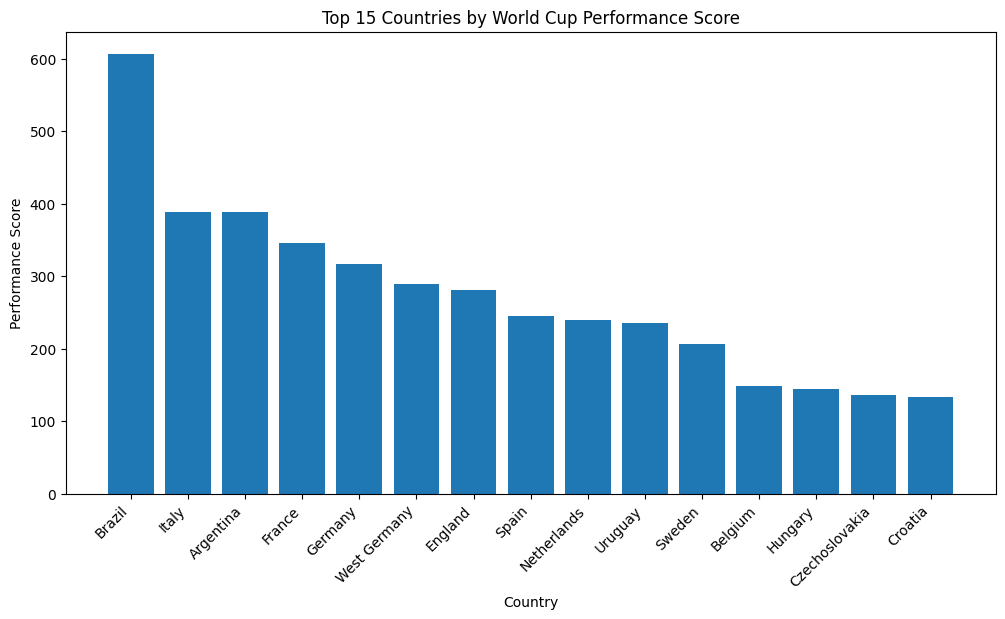

In [21]:
top_performance = performance_score.head(15)

plt.figure(figsize=(12,6))
plt.bar(top_performance['team'], top_performance['total_performance_score'])
plt.title('Top 15 Countries by World Cup Performance Score')
plt.xlabel('Country')
plt.ylabel('Performance Score')
plt.xticks(rotation=45, ha='right')
plt.show()

## Preparing for Population Analysis

The main research question requires population data.

The next step is to join this World Cup performance data with a population dataset that includes:

- country
- year
- population

Once added, the final metric will be:

World Cup Efficiency Index = Total Performance Score / Population in Millions

## World Cup Efficiency Index

The World Cup Efficiency Index, or WCEI, measures how much World Cup success a country has achieved relative to its population size.

A higher score means a country has produced strong World Cup results despite having a smaller population.

Formula:

WCEI = Total Performance Score / Population in Millions

## Load Population Dataset

To answer the main research question, I added population data. This allows World Cup performance to be adjusted by country population.

The population dataset should include:

- Country Name
- Country Code
- Year
- Value

In [22]:
conn.sql("""
CREATE TABLE population_raw AS
SELECT *
FROM read_csv_auto('/Users/ajnursivac/Desktop/Projects/population.csv');
""")
         

In [23]:
conn.sql("""
SELECT *
FROM population_raw
LIMIT 10;
""").df()

,Country Name,Country Code,Year,Value
0,Aruba,ABW,1960,54922
1,Aruba,ABW,1961,55578
2,Aruba,ABW,1962,56320
3,Aruba,ABW,1963,57002
4,Aruba,ABW,1964,57619
5,Aruba,ABW,1965,58190
6,Aruba,ABW,1966,58694
7,Aruba,ABW,1967,58990
8,Aruba,ABW,1968,59069
9,Aruba,ABW,1969,59052


## Inspect Population Data

In [24]:
conn.sql("""
DESCRIBE population_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,Country Name,VARCHAR,YES,None,None,None
1,Country Code,VARCHAR,YES,None,None,None
2,Year,BIGINT,YES,None,None,None
3,Value,BIGINT,YES,None,None,None


## Clean Population Data

The population file uses generic column names. I cleaned the table by renaming columns into a simpler SQL-friendly format.

In [25]:
conn.sql("""
CREATE TABLE population AS
SELECT
    "Country Name" AS country,
    "Country Code" AS country_code,
    Year AS year,
    Value AS population
FROM population_raw
WHERE Year BETWEEN 1930 AND 2022;
""")

In [26]:
conn.sql("""
SELECT *
FROM population
LIMIT 10;
""").df()

,country,country_code,year,population
0,Aruba,ABW,1960,54922
1,Aruba,ABW,1961,55578
2,Aruba,ABW,1962,56320
3,Aruba,ABW,1963,57002
4,Aruba,ABW,1964,57619
5,Aruba,ABW,1965,58190
6,Aruba,ABW,1966,58694
7,Aruba,ABW,1967,58990
8,Aruba,ABW,1968,59069
9,Aruba,ABW,1969,59052


## Filter Population to World Cup Years

The World Cup does not happen every year, so I filtered the population table to only include tournament years from 1930 through 2022.

In [27]:
conn.sql("""
CREATE TABLE world_cup_population AS
SELECT *
FROM population
WHERE year IN (
    1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966,
    1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998,
    2002, 2006, 2010, 2014, 2018, 2022
);
""")

In [28]:
conn.sql("""
SELECT *
FROM world_cup_population
ORDER BY country, year
LIMIT 20;
""").df()

,country,country_code,year,population
0,Afghanistan,AFG,1962,9404406
1,Afghanistan,AFG,1966,10266395
2,Afghanistan,AFG,1970,11290128
3,Afghanistan,AFG,1974,12469127
4,Afghanistan,AFG,1978,13611441
5,Afghanistan,AFG,1982,10991378
6,Afghanistan,AFG,1986,11420074
7,Afghanistan,AFG,1990,12045660
8,Afghanistan,AFG,1994,16250794
9,Afghanistan,AFG,1998,19159996


## Create Country Name Mapping

Some country names in the World Cup dataset do not exactly match the population dataset.

For example:

- USA = United States
- South Korea = Korea, Rep.
- Iran = Iran, Islamic Rep.

To fix this, I created a mapping table.

In [29]:
conn.sql("""
CREATE TABLE country_mapping (
    world_cup_team VARCHAR,
    population_country VARCHAR
);

INSERT INTO country_mapping VALUES
    ('USA', 'United States'),
    ('United States', 'United States'),
    ('South Korea', 'Korea, Rep.'),
    ('North Korea', 'Korea, Dem. People''s Rep.'),
    ('Iran', 'Iran, Islamic Rep.'),
    ('Russia', 'Russian Federation'),
    ('Egypt', 'Egypt, Arab Rep.'),
    ('Czech Republic', 'Czechia'),
    ('Czechia', 'Czechia'),
    ('Slovakia', 'Slovak Republic'),
    ('Turkey', 'Turkiye'),
    ('Türkiye', 'Turkiye'),
    ('Ivory Coast', 'Cote d''Ivoire'),
    ('Côte d’Ivoire', 'Cote d''Ivoire'),
    ('England', 'United Kingdom'),
    ('Scotland', 'United Kingdom'),
    ('Wales', 'United Kingdom'),
    ('Northern Ireland', 'United Kingdom'),
    ('Yugoslavia', 'Serbia'),
    ('Serbia and Montenegro', 'Serbia');
""")

## Create Tournament-Level Performance

Instead of only calculating all-time totals, I calculated performance by country and tournament year. This allows each country to be joined to population data from the same World Cup year.

In [30]:
conn.sql("""
CREATE TABLE tournament_performance AS
SELECT
    Year,
    team,
    COUNT(*) AS matches_played,
    SUM(CASE WHEN result = 'Win' THEN 1 ELSE 0 END) AS wins,
    SUM(CASE WHEN result = 'Draw' THEN 1 ELSE 0 END) AS draws,
    SUM(CASE WHEN result = 'Loss' THEN 1 ELSE 0 END) AS losses,
    SUM(goals_for) AS goals_for,
    SUM(goals_against) AS goals_against,

    SUM(
        CASE 
            WHEN result = 'Win' THEN 3
            WHEN result = 'Draw' THEN 1
            ELSE 0
        END
    )
    +
    SUM(
        CASE
            WHEN Round ILIKE '%Final%' THEN 10
            WHEN Round ILIKE '%Semi%' THEN 7
            WHEN Round ILIKE '%Quarter%' THEN 5
            WHEN Round ILIKE '%Round of 16%' THEN 3
            ELSE 0
        END
    ) AS performance_score

FROM team_matches
GROUP BY Year, team;
""")

In [31]:
conn.sql("""
SELECT *
FROM tournament_performance
ORDER BY Year, performance_score DESC
LIMIT 20;
""").df()

,Year,team,matches_played,wins,draws,losses,goals_for,goals_against,performance_score
0,1930,Uruguay,4,4.0,0.0,0.0,15.0,3.0,32.0
1,1930,Argentina,5,4.0,0.0,1.0,18.0,9.0,32.0
2,1930,United States,3,2.0,0.0,1.0,7.0,6.0,16.0
3,1930,Yugoslavia,3,2.0,0.0,1.0,7.0,7.0,16.0
4,1930,Chile,3,2.0,0.0,1.0,5.0,3.0,6.0
5,1930,Paraguay,2,1.0,0.0,1.0,1.0,3.0,3.0
6,1930,Romania,2,1.0,0.0,1.0,3.0,5.0,3.0
7,1930,France,3,1.0,0.0,2.0,4.0,3.0,3.0
8,1930,Brazil,2,1.0,0.0,1.0,5.0,2.0,3.0
9,1930,Bolivia,2,0.0,0.0,2.0,0.0,8.0,0.0


## Join World Cup Performance with Population

This step combines tournament performance with population data.

The join uses:

- Country name
- Tournament year

In [32]:
wcei_by_tournament = conn.sql("""
WITH performance_with_mapping AS (
    SELECT
        tp.Year,
        tp.team,
        COALESCE(cm.population_country, tp.team) AS population_country,
        tp.matches_played,
        tp.wins,
        tp.draws,
        tp.losses,
        tp.goals_for,
        tp.goals_against,
        tp.performance_score
    FROM tournament_performance tp
    LEFT JOIN country_mapping cm
        ON tp.team = cm.world_cup_team
)

SELECT
    pwm.Year,
    pwm.team,
    pwm.population_country,
    pwm.matches_played,
    pwm.wins,
    pwm.draws,
    pwm.losses,
    pwm.goals_for,
    pwm.goals_against,
    pwm.performance_score,
    wcp.population,
    ROUND(wcp.population / 1000000.0, 2) AS population_millions,
    ROUND(pwm.performance_score / (wcp.population / 1000000.0), 2) AS wcei
FROM performance_with_mapping pwm
JOIN world_cup_population wcp
    ON pwm.population_country = wcp.country
   AND pwm.Year = wcp.year
WHERE wcp.population IS NOT NULL
ORDER BY wcei DESC;
""").df()

wcei_by_tournament.head(20)

,Year,team,population_country,matches_played,wins,draws,losses,goals_for,goals_against,performance_score,population,population_millions,wcei
0,2018,Croatia,Croatia,7,6.0,0.0,1.0,14.0,9.0,51.0,3988775,3.99,12.79
1,2010,Uruguay,Uruguay,7,4.0,1.0,2.0,11.0,8.0,36.0,3318580,3.32,10.85
2,1970,Uruguay,Uruguay,6,2.0,1.0,3.0,4.0,5.0,27.0,2790807,2.79,9.67
3,2022,Croatia,Croatia,7,4.0,2.0,1.0,8.0,7.0,37.0,3855641,3.86,9.60
4,1998,Croatia,Croatia,7,5.0,0.0,2.0,11.0,5.0,38.0,4532135,4.53,8.38
5,2018,Uruguay,Uruguay,5,4.0,0.0,1.0,7.0,3.0,25.0,3394534,3.39,7.36
6,1966,Uruguay,Uruguay,4,1.0,2.0,1.0,2.0,5.0,15.0,2707646,2.71,5.54
7,2014,Costa Rica,Costa Rica,5,3.0,1.0,1.0,5.0,2.0,23.0,4767119,4.77,4.82
8,1962,Yugoslavia,Serbia,6,3.0,0.0,3.0,10.0,7.0,29.0,6740264,6.74,4.30
9,1994,Sweden,Sweden,7,4.0,2.0,1.0,15.0,8.0,37.0,8780745,8.78,4.21


## Top Single-Tournament Overperformers

This table shows the best World Cup performances relative to population in a single tournament year.

In [33]:
wcei_by_tournament.head(20)

,Year,team,population_country,matches_played,wins,draws,losses,goals_for,goals_against,performance_score,population,population_millions,wcei
0,2018,Croatia,Croatia,7,6.0,0.0,1.0,14.0,9.0,51.0,3988775,3.99,12.79
1,2010,Uruguay,Uruguay,7,4.0,1.0,2.0,11.0,8.0,36.0,3318580,3.32,10.85
2,1970,Uruguay,Uruguay,6,2.0,1.0,3.0,4.0,5.0,27.0,2790807,2.79,9.67
3,2022,Croatia,Croatia,7,4.0,2.0,1.0,8.0,7.0,37.0,3855641,3.86,9.60
4,1998,Croatia,Croatia,7,5.0,0.0,2.0,11.0,5.0,38.0,4532135,4.53,8.38
5,2018,Uruguay,Uruguay,5,4.0,0.0,1.0,7.0,3.0,25.0,3394534,3.39,7.36
6,1966,Uruguay,Uruguay,4,1.0,2.0,1.0,2.0,5.0,15.0,2707646,2.71,5.54
7,2014,Costa Rica,Costa Rica,5,3.0,1.0,1.0,5.0,2.0,23.0,4767119,4.77,4.82
8,1962,Yugoslavia,Serbia,6,3.0,0.0,3.0,10.0,7.0,29.0,6740264,6.74,4.30
9,1994,Sweden,Sweden,7,4.0,2.0,1.0,15.0,8.0,37.0,8780745,8.78,4.21


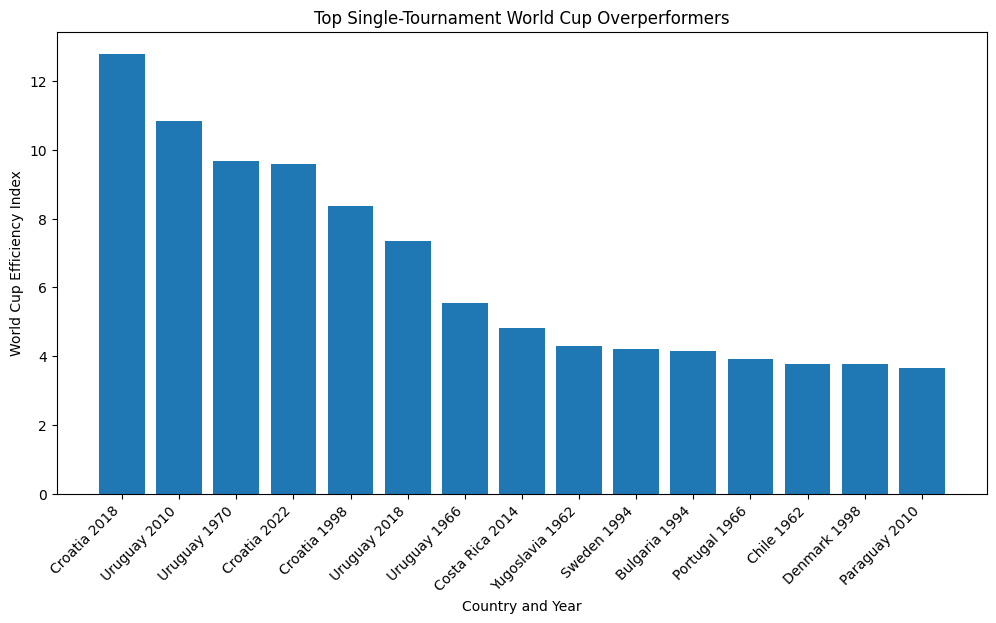

In [34]:
top_wcei_single = wcei_by_tournament.head(15)

plt.figure(figsize=(12,6))
plt.bar(
    top_wcei_single['team'] + ' ' + top_wcei_single['Year'].astype(str),
    top_wcei_single['wcei']
)
plt.title('Top Single-Tournament World Cup Overperformers')
plt.xlabel('Country and Year')
plt.ylabel('World Cup Efficiency Index')
plt.xticks(rotation=45, ha='right')
plt.show()

## All-Time World Cup Efficiency Index

Next, I calculated each country's total performance score across all tournaments and divided it by the country's average population during the World Cup years in which it participated.

In [35]:
all_time_wcei = conn.sql("""
WITH performance_with_mapping AS (
    SELECT
        tp.Year,
        tp.team,
        COALESCE(cm.population_country, tp.team) AS population_country,
        tp.performance_score
    FROM tournament_performance tp
    LEFT JOIN country_mapping cm
        ON tp.team = cm.world_cup_team
),

joined AS (
    SELECT
        pwm.Year,
        pwm.team,
        pwm.performance_score,
        wcp.population
    FROM performance_with_mapping pwm
    JOIN world_cup_population wcp
        ON pwm.population_country = wcp.country
       AND pwm.Year = wcp.year
    WHERE wcp.population IS NOT NULL
),

country_totals AS (
    SELECT
        team,
        COUNT(DISTINCT Year) AS tournaments_played,
        SUM(performance_score) AS total_performance_score,
        AVG(population) AS avg_population
    FROM joined
    GROUP BY team
)

SELECT
    DENSE_RANK() OVER (
        ORDER BY total_performance_score / (avg_population / 1000000.0) DESC
    ) AS wcei_rank,
    team,
    tournaments_played,
    total_performance_score,
    ROUND(avg_population / 1000000.0, 2) AS avg_population_millions,
    ROUND(total_performance_score / (avg_population / 1000000.0), 2) AS wcei
FROM country_totals
WHERE tournaments_played >= 2
ORDER BY wcei_rank;
""").df()

all_time_wcei.head(25)

,wcei_rank,team,tournaments_played,total_performance_score,avg_population_millions,wcei
0,1,Uruguay,11,134.0,3.07,43.58
1,2,Croatia,6,134.0,4.20,31.92
2,3,Netherlands,9,234.0,15.67,14.93
3,4,Belgium,10,142.0,10.43,13.61
4,5,Portugal,8,121.0,10.20,11.86
5,6,Argentina,15,351.0,34.11,10.29
6,7,Sweden,8,88.0,8.75,10.06
7,8,Denmark,6,54.0,5.51,9.80
8,9,Paraguay,5,47.0,5.00,9.39
9,10,Costa Rica,6,40.0,4.39,9.12


## Visualize All-Time Overperformers

This chart shows the top countries by all-time World Cup Efficiency Index.

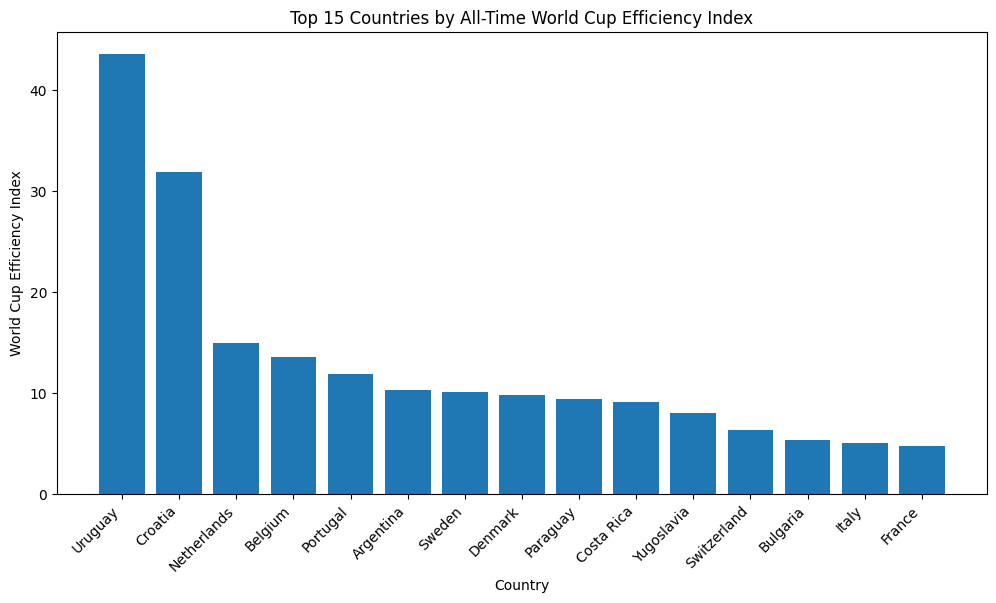

In [36]:
top_all_time_wcei = all_time_wcei.head(15)

plt.figure(figsize=(12,6))
plt.bar(top_all_time_wcei['team'], top_all_time_wcei['wcei'])
plt.title('Top 15 Countries by All-Time World Cup Efficiency Index')
plt.xlabel('Country')
plt.ylabel('World Cup Efficiency Index')
plt.xticks(rotation=45, ha='right')
plt.show()

## Compare Raw Performance vs Population-Adjusted Performance

A country can dominate in raw World Cup success but rank differently after adjusting for population.

This comparison helps separate traditional football powers from true population-adjusted overperformers.

In [37]:
comparison = conn.sql("""
WITH raw_performance AS (
    SELECT
        team,
        SUM(performance_score) AS total_performance_score
    FROM tournament_performance
    GROUP BY team
),

performance_with_mapping AS (
    SELECT
        tp.Year,
        tp.team,
        COALESCE(cm.population_country, tp.team) AS population_country,
        tp.performance_score
    FROM tournament_performance tp
    LEFT JOIN country_mapping cm
        ON tp.team = cm.world_cup_team
),

joined AS (
    SELECT
        pwm.Year,
        pwm.team,
        pwm.performance_score,
        wcp.population
    FROM performance_with_mapping pwm
    JOIN world_cup_population wcp
        ON pwm.population_country = wcp.country
       AND pwm.Year = wcp.year
    WHERE wcp.population IS NOT NULL
),

wcei AS (
    SELECT
        team,
        COUNT(DISTINCT Year) AS tournaments_played,
        SUM(performance_score) AS total_performance_score,
        AVG(population) AS avg_population,
        SUM(performance_score) / (AVG(population) / 1000000.0) AS wcei
    FROM joined
    GROUP BY team
)

SELECT
    team,
    tournaments_played,
    total_performance_score,
    ROUND(avg_population / 1000000.0, 2) AS avg_population_millions,
    ROUND(wcei, 2) AS wcei,
    DENSE_RANK() OVER (ORDER BY total_performance_score DESC) AS raw_performance_rank,
    DENSE_RANK() OVER (ORDER BY wcei DESC) AS population_adjusted_rank
FROM wcei
WHERE tournaments_played >= 2
ORDER BY population_adjusted_rank
LIMIT 25;
""").df()

comparison

,team,tournaments_played,total_performance_score,avg_population_millions,wcei,raw_performance_rank,population_adjusted_rank
0,Uruguay,11,134.0,3.07,43.58,10,1
1,Croatia,6,134.0,4.20,31.92,10,2
2,Netherlands,9,234.0,15.67,14.93,6,3
3,Belgium,10,142.0,10.43,13.61,9,4
4,Portugal,8,121.0,10.20,11.86,11,5
5,Argentina,15,351.0,34.11,10.29,2,6
6,Sweden,8,88.0,8.75,10.06,13,7
7,Denmark,6,54.0,5.51,9.80,17,8
8,Paraguay,5,47.0,5.00,9.39,21,9
9,Costa Rica,6,40.0,4.39,9.12,24,10


## Key Findings

The analysis shows that raw World Cup success and population-adjusted success tell different stories.

Traditional football powers often dominate total wins and total performance score. However, once population is considered, smaller countries can rise significantly in the rankings.

This supports the idea that some countries have historically overperformed relative to the size of their population.

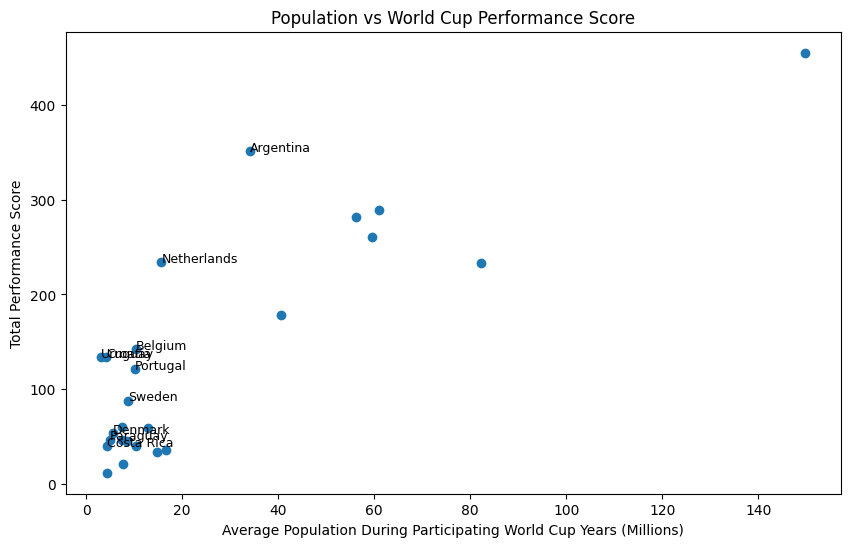

In [38]:
plt.figure(figsize=(10,6))
plt.scatter(
    comparison['avg_population_millions'],
    comparison['total_performance_score']
)
plt.title('Population vs World Cup Performance Score')
plt.xlabel('Average Population During Participating World Cup Years (Millions)')
plt.ylabel('Total Performance Score')

for i in range(min(10, len(comparison))):
    plt.text(
        comparison['avg_population_millions'][i],
        comparison['total_performance_score'][i],
        comparison['team'][i],
        fontsize=9
    )

plt.show()

 ## Final Conclusion

This project analyzed FIFA World Cup match data from 1930 to 2022 using SQL and Python to investigate the following research question:

**Which countries have achieved the greatest FIFA World Cup success relative to their population?**

The analysis demonstrated that traditional football powers such as Brazil, Germany, Argentina, Italy, and France dominate raw measures of World Cup success, including championships, match wins, and goals scored. However, when performance is adjusted for population size, a different perspective emerges.

Uruguay is one of the strongest historical examples of a nation outperforming expectations. Despite having a population of only a few million people, Uruguay won the FIFA World Cup in 1930 and 1950 and has remained one of the most successful football nations in history relative to its population.

Croatia represents a modern example of sustained overperformance. Since becoming an independent nation, Croatia has reached the FIFA World Cup Final in 2018 and earned third-place finishes in 1998 and 2022. These achievements demonstrate how a relatively small nation can consistently compete among the world's elite teams.

Several additional World Cup performances support the findings of this analysis. Cameroon became the first African nation to reach the quarterfinals in 1990. South Korea advanced to the semifinals as co-hosts in 2002. Costa Rica exceeded expectations by winning the "Group of Death" and reaching the quarterfinals in 2014. Morocco became the first African nation to reach the World Cup semifinals in 2022. These accomplishments illustrate that exceptional player development, tactical organization, and football culture can overcome limitations associated with population size.

The project also highlights how the underdog story continues to evolve. Entering the 2026 FIFA World Cup, Cape Verde has emerged as one of the tournament's Cinderella stories. As one of the smallest nations ever to qualify for the World Cup, Cape Verde demonstrated that countries with limited populations can compete successfully on the international stage.

To better evaluate these performances, this project introduced the **World Cup Efficiency Index (WCEI)**, a custom metric that measures World Cup success relative to population size. This metric provides a more balanced comparison of national team performance by accounting for differences in available talent pools.

Throughout this project, the following data science and analytics skills were demonstrated:

* SQL
* DuckDB
* Python
* Data cleaning
* Data transformation
* SQL joins
* Common Table Expressions (CTEs)
* CASE statements
* Aggregations
* Window functions
* Feature engineering
* Exploratory data analysis (EDA)
* Data visualization
* Analytical storytelling

Overall, this analysis demonstrates that population size alone does not determine international football success. Countries such as Uruguay, Croatia, Cameroon, South Korea, Costa Rica, and Morocco have consistently achieved results that exceed expectations based on population. The World Cup Efficiency Index provides a meaningful framework for identifying nations that maximize their football success and offers a new perspective on one of the world's most celebrated sporting competitions.
